## Lab 1
#### Name: Madhura Likhar
#### Section : C
#### Roll no.:C2_22

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
df.shape

(891, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.drop("Cabin", axis=1, inplace=True) #cannot be brought back once deleted

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.duplicated().sum()

np.int64(0)

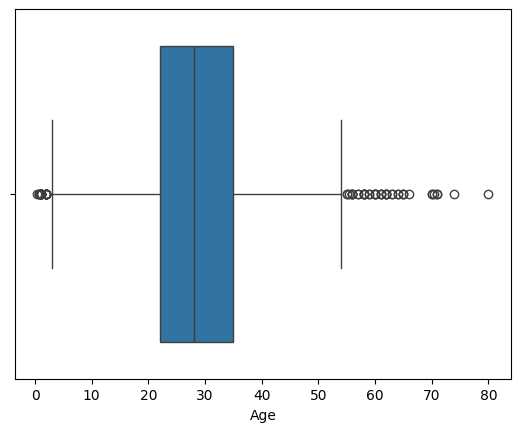

In [ ]:
import seaborn as sns
sns.boxplot(x=df["Age"])
plt.show()

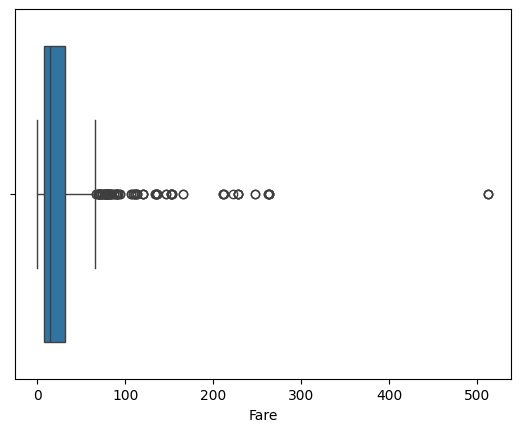

In [ ]:
sns.boxplot(x=df["Fare"])
plt.show()

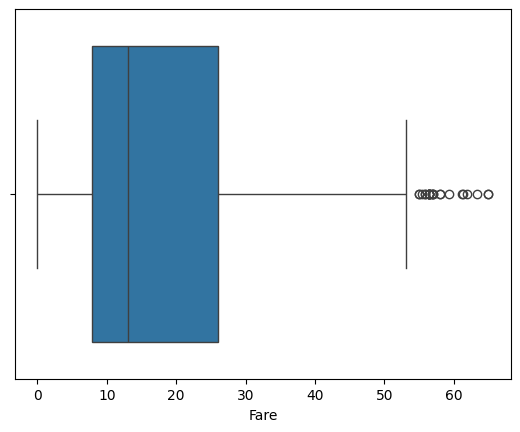

In [ ]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

import seaborn as sns
sns.boxplot(x=df["Fare"])
plt.show()


In [ ]:
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [ ]:
df = pd.get_dummies(df, columns=["Embarked"])

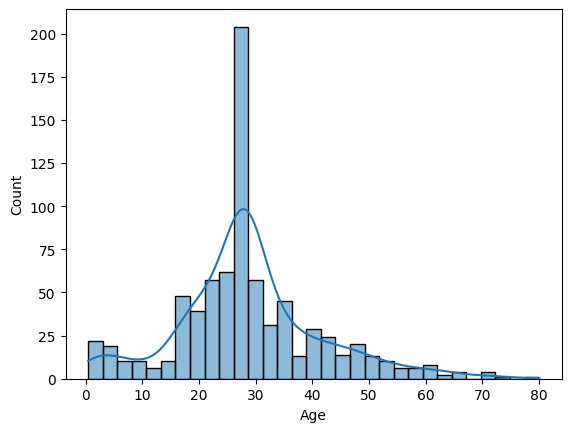

In [ ]:
sns.histplot(df["Age"], kde = True) #kde responsible for making that line

plt.show()

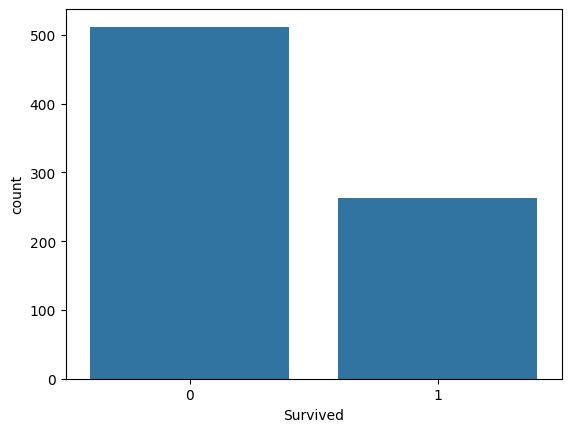

In [ ]:

sns.countplot(x="Survived", data = df)
plt.show()
#univariant analysis

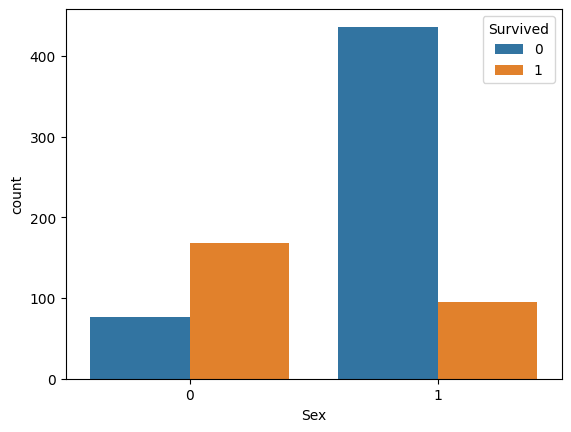

In [ ]:
#bivariant analysis
sns.countplot(x="Sex",hue = "Survived", data = df)
plt.show()

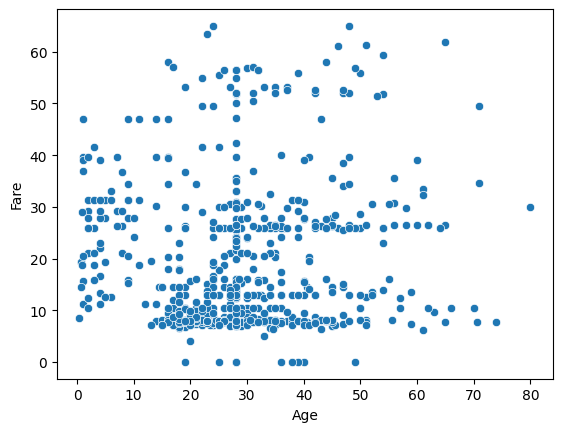

In [ ]:
#scatterplot
sns.scatterplot(x="Age", y = "Fare", data = df)
plt.show()

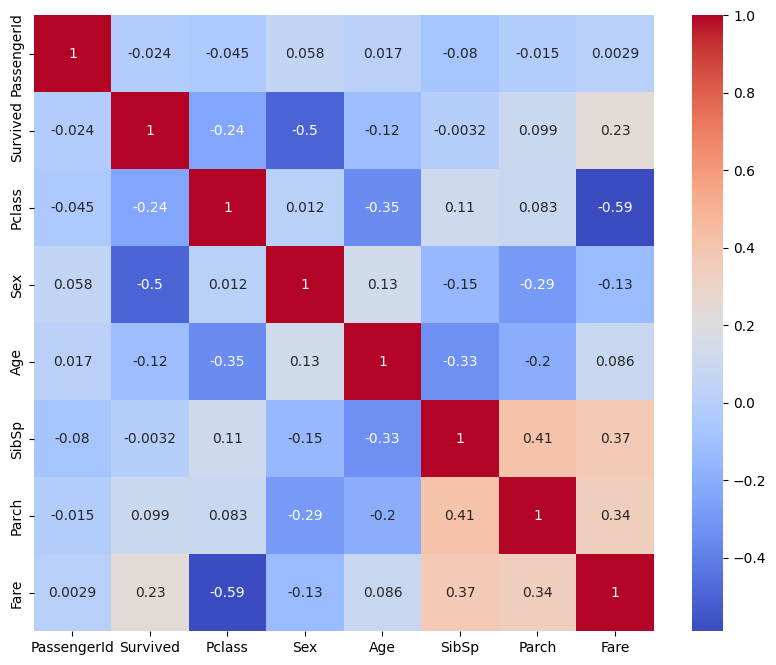

In [ ]:
#multivariant analysis
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

#-0.111 etc means their correlation -ve or +ve

In [ ]:
scaler = StandardScaler()
df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
X = X.drop(["PassengerId","Name", "Ticket"],axis=1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

In [ ]:
print(X_train.shape)

(620, 9)


In [ ]:
print(X_test.shape)

(155, 9)


In [ ]:
print(y_train.shape)

(620,)


In [ ]:
print(y_test.shape)

(155,)


In [ ]:
# feature scaling
x=df.drop("Survived", axis =1)
y=df["Survived"]

In [ ]:
#standard scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[["Age","Fare"]]=scaler.fit_transform(X[["Age","Fare"]])

In [ ]:
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,-0.528321,1,0,-0.779117,False,False,True
2,3,0,-0.215182,0,0,-0.729373,False,False,True
3,1,0,0.489381,1,0,2.599828,False,False,True
4,3,1,0.489381,0,0,-0.720161,False,False,True
5,3,1,-0.058613,0,0,-0.690071,False,True,False
6,1,1,1.976792,0,0,2.508630,False,False,True
7,3,1,-2.094017,3,1,0.239725,False,False,True
8,3,0,-0.136897,0,2,-0.492935,False,False,True
9,2,0,-1.154600,1,0,0.902677,True,False,False
10,3,0,-1.937447,1,1,-0.082693,False,False,True


In [ ]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)